# SIOC 251 – Homework 0

## Computing Environment Setup and Optical Dispersion

**Name:** Claire Liu   
**Date:** 4/7/26

In [90]:
import numpy as np
import matplotlib.pyplot as plt

In [91]:
#Refractive Index Functions
def n_of_lam(lam):
    return 1.50 + 0.004 / lam**2

#Snell's law
def snell_scalar(n1, n2, theta):
    s = n1 / n2 * np.sin(theta)
    if abs(s) > 1.0:
        return None
    return np.arcsin(s)

def vector_refract(d_in, n_surface, n1, n2):
    """
    Vector Snell's law.
    d_in:      unit incident direction
    n_surface: unit surface normal pointing INTO the medium the ray comes FROM
    n1, n2:    refractive indices (from → to)
    Returns unit refracted direction, or None for TIR.
    """
    cos_i = -np.dot(d_in, n_surface)
    if cos_i < 0:
        n_surface = -n_surface
        cos_i = -np.dot(d_in, n_surface)
    r = n1 / n2
    sin2_t = r**2 * (1 - cos_i**2)
    if sin2_t > 1.0:
        return None
    cos_t = np.sqrt(1 - sin2_t)
    d_out = r * d_in + (r * cos_i - cos_t) * n_surface
    return d_out / np.linalg.norm(d_out)

def ray_segment_intersect(origin, direction, p1, p2):
    """
    Intersection of ray origin+t*direction with segment p1→p2.
    Solves: origin + t*D = p1 + s*(p2 - p1)
    Returns (t, s, point) or (None, None, None).
    """
    v = p2 - p1
    # 2×2 system via Cramer's rule
    det = direction[0] * (-v[1]) - direction[1] * (-v[0])
    if abs(det) < 1e-12:
        return None, None, None
    rhs = p1 - origin
    t = (rhs[0] * (-v[1]) - rhs[1] * (-v[0])) / det
    s = (direction[0] * rhs[1] - direction[1] * rhs[0]) / det
    if t > 1e-8 and -1e-6 <= s <= 1 + 1e-6:
        return t, s, origin + t * direction
    return None, None, None

In [92]:
WAVELENGTHS = [
    ("Violet", 0.40, "#8B00FF"),
    ("Blue",   0.45, "#0000FF"),
    ("Cyan",   0.50, "#00BBCC"),
    ("Green",  0.55, "#00AA00"),
    ("Yellow", 0.58, "#CCCC00"),
    ("Orange", 0.62, "#FF8800"),
    ("Red",    0.70, "#FF0000"),
]

APEX_DEG = 60.0
APEX = np.radians(APEX_DEG)
THETA_I_DEG = 45.0
THETA_I = np.radians(THETA_I_DEG)

## Model Verification

If the model works correctly, a light hitting a surface head-on (θᵢ = 0°) shouldn't bend at all. I verify that Snell's law returns θₜ = 0°. And if a ray goes from air into glass and bends to some angle, then a ray at that angle going from glass back into air should recover the original angle. I send 30° into glass, get the refracted angle, then reverse the process and check I got 30° back. This confirms the function is consistent in both directions.

In [93]:
#Normal incidence
assert np.isclose(snell_scalar(1.0, 1.5, 0.0), 0)
print("Normal incidence → θ_t = 0°")

#Reciprocity
th_in = snell_scalar(1.0, 1.5, np.radians(30))
th_out = snell_scalar(1.5, 1.0, th_in)
assert np.isclose(th_out, np.radians(30), atol=1e-12)
print(f"Reciprocity: 30° → glass → air = {np.degrees(th_out):.4f}°")


Normal incidence → θ_t = 0°
Reciprocity: 30° → glass → air = 30.0000°


In [94]:
#PRISM GEOMETRY

SIDE = 5.0
h = SIDE * np.sqrt(3) / 2
B  = np.array([2.5, 0.0])       # bottom-left
C  = np.array([7.5, 0.0])       # bottom-right
Ap = np.array([5.0, h])         # apex
centroid = (Ap + B + C) / 3.0

def make_outward_normal(p1, p2, interior):
    edge = p2 - p1
    n = np.array([-edge[1], edge[0]])
    if np.dot(n, interior - (p1 + p2) / 2) > 0:
        n = -n
    return n / np.linalg.norm(n)

faces = {
    "left":   {"p1": Ap, "p2": B},
    "bottom": {"p1": B,  "p2": C},
    "right":  {"p1": C,  "p2": Ap},
}
for fn in faces:
    f = faces[fn]
    f["normal"] = make_outward_normal(f["p1"], f["p2"], centroid)

In [95]:
#RAY TRACING FUNCTION
def trace_ray(entry_face_name, entry_point, incident_dir, n_prism):
    """Trace a ray through the prism. Returns dict or None."""
    f_entry = faces[entry_face_name]
    n_out = f_entry["normal"]

    # Refract into prism (air → glass)
    d_inside = vector_refract(incident_dir, n_out, 1.0, n_prism)
    if d_inside is None:
        return None

    # Find exit face
    best_t = np.inf
    exit_face_name = None
    exit_point = None
    for fn, f in faces.items():
        if fn == entry_face_name:
            continue
        t, s, pt = ray_segment_intersect(entry_point, d_inside, f["p1"], f["p2"])
        if t is not None and t < best_t:
            best_t, exit_face_name, exit_point = t, fn, pt

    if exit_point is None:
        return None

    # Refract out of prism (glass → air)
    n_out_exit = faces[exit_face_name]["normal"]
    d_exit = vector_refract(d_inside, n_out_exit, n_prism, 1.0)
    if d_exit is None:
        return None

    source = entry_point - 4.0 * incident_dir
    far = exit_point + 5.5 * d_exit

    return {
        "points": [source, entry_point.copy(), exit_point, far],
        "d_inside": d_inside, "d_exit": d_exit,
        "exit_face": exit_face_name,
    }

In [96]:
#SET UP INCIDENT BEAM
f_left = faces["left"]
n_out_left = f_left["normal"]
entry_pt = (f_left["p1"] + f_left["p2"]) / 2.0

tang = f_left["p2"] - f_left["p1"]
tang /= np.linalg.norm(tang)

candidates = []
for s in [1, -1]:
    d = -np.cos(THETA_I) * n_out_left + np.sin(THETA_I) * s * tang
    d /= np.linalg.norm(d)
    if d[0] > 0:
        candidates.append(d)
# Pick the more horizontal ray
incident_dir = max(candidates, key=lambda d: d[0])

cos_check = -np.dot(incident_dir, n_out_left)
print(f"Incident angle: {np.degrees(np.arccos(cos_check)):.1f}° ")
print(f"Incident direction: {incident_dir}")

Incident angle: 45.0° 
Incident direction: [0.96592583 0.25881905]


In [97]:
#TRACE ALL WAVELENGTHS
print(f"\n{'Color':<8} {'λ(μm)':>6} {'n':>8} {'Exit':>6} {'δ(°)':>8}")
print("-" * 40)

all_results = []
for name, lam, col in WAVELENGTHS:
    n = n_of_lam(lam)
    result = trace_ray("left", entry_pt.copy(), incident_dir, n)
    if result is None:
        print(f"{name:<8} {lam:>6.2f} {n:>8.5f}  FAIL")
        continue

    cos_dev = np.dot(incident_dir, result["d_exit"])
    delta = np.degrees(np.arccos(np.clip(cos_dev, -1, 1)))

    result.update({"name": name, "lam": lam, "col": col, "n": n, "delta": delta})
    all_results.append(result)
    print(f"{name:<8} {lam:>6.2f} {n:>8.5f} {result['exit_face']:>6} {delta:>8.3f}")

spread = all_results[0]["delta"] - all_results[-1]["delta"]
print(f"\nAngular spread (Violet − Red): {spread:.3f}°")


Color     λ(μm)        n   Exit     δ(°)
----------------------------------------
Violet     0.40  1.52500  right   39.744
Blue       0.45  1.51975  right   39.238
Cyan       0.50  1.51600  right   38.879
Green      0.55  1.51322  right   38.616
Yellow     0.58  1.51189  right   38.490
Orange     0.62  1.51041  right   38.350
Red        0.70  1.50816  right   38.140

Angular spread (Violet − Red): 1.604°


## Figure

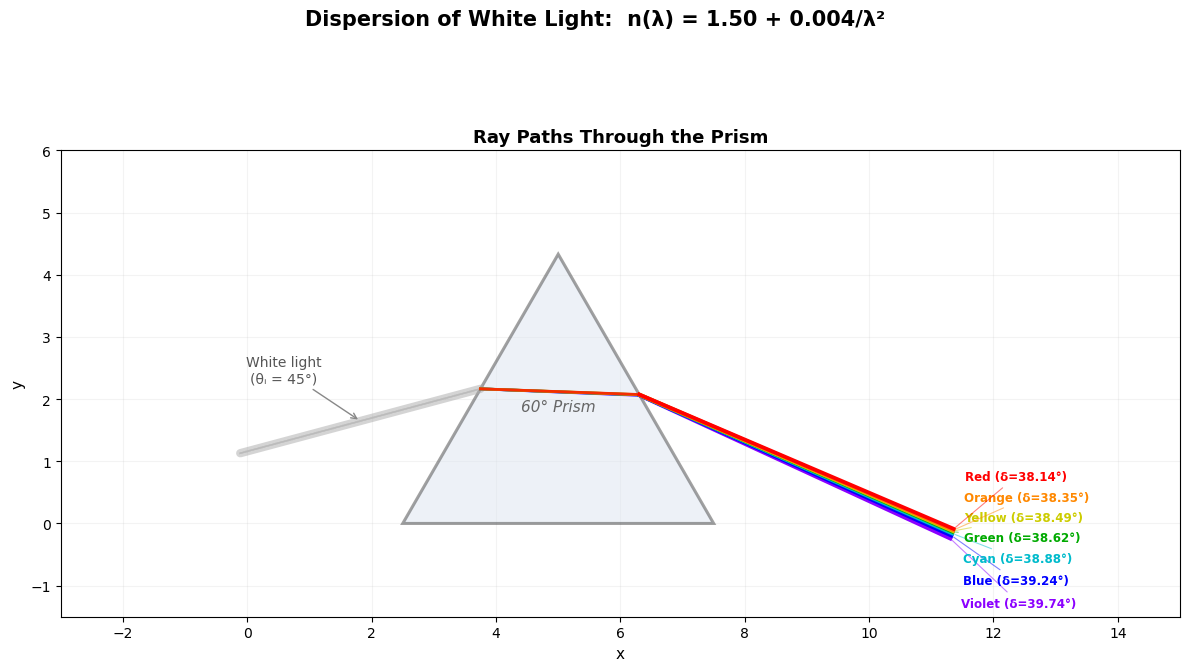

In [98]:
fig, ax_main = plt.subplots(figsize=(12, 7))
 
tri = plt.Polygon([B, C, Ap], closed=True,
                   facecolor='#dde5f0', edgecolor='#444',
                   linewidth=2.2, alpha=0.5, zorder=2)
ax_main.add_patch(tri)
 
# White incident beam
src = entry_pt - 4.0 * incident_dir
ax_main.plot([src[0], entry_pt[0]], [src[1], entry_pt[1]],
             color='#aaa', linewidth=6, solid_capstyle='round',
             zorder=2.3, alpha=0.5)
ax_main.annotate("White light\n(θᵢ = 45°)",
                 xy=(src + entry_pt) / 2, fontsize=10, color='#555',
                 ha='center', xytext=(-55, 28), textcoords='offset points',
                 arrowprops=dict(arrowstyle='->', color='#888'))
 
for idx, r in enumerate(all_results):
    pts = r["points"]
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
 
    ax_main.plot([xs[0], xs[1]], [ys[0], ys[1]],
                 color='#bbb', lw=1, alpha=0.3, zorder=2.4)
    ax_main.plot([xs[1], xs[2]], [ys[1], ys[2]],
                 color=r["col"], lw=2.0, alpha=0.7, zorder=3)
    ax_main.plot([xs[2], xs[3]], [ys[2], ys[3]],
                 color=r["col"], lw=2.8, zorder=4)
 
    # Stagger labels vertically so they don't overlap
    y_offset = 14 * (idx - len(all_results) / 2)
    ax_main.annotate(f"{r['name']} (δ={r['delta']:.2f}°)",
                     xy=(xs[3], ys[3]), fontsize=8.5,
                     fontweight='bold', color=r["col"],
                     xytext=(8, y_offset), textcoords='offset points',
                     arrowprops=dict(arrowstyle='-', color=r["col"],
                                     lw=0.8, alpha=0.5),
                     zorder=5)
 
ax_main.set_xlim(-3, 15)
ax_main.set_ylim(-1.5, 6)
ax_main.set_aspect('equal')
ax_main.set_title("Ray Paths Through the Prism", fontsize=13, fontweight='bold')
ax_main.set_xlabel("x", fontsize=11)
ax_main.set_ylabel("y", fontsize=11)
ax_main.grid(True, alpha=0.15)
ax_main.text(5.0, 1.8, "60° Prism", ha='center', fontsize=11,
             color='#666', style='italic')
 
fig.suptitle("Dispersion of White Light:  n(λ) = 1.50 + 0.004/λ²",
             fontsize=15, fontweight='bold', y=1.01)
fig.tight_layout()
fig.savefig("figures/prism_dispersion.png", dpi=200, bbox_inches='tight')
 

## Interpretations

Since n(λ) = 1.50 + 0.004/λ² gives higher n for shorter wavelengths, violet gets bent the most and red the least. This means red should exit closest to the original beam path and violet furthest away, which is what the album cover shows. The ordering is physically consistent.
Based on the ray-tracing figure, the simulation confirms this. Violet exits at δ = 39.74° and red at δ = 38.14°, with all other colors falling in between in the correct rainbow order. However, the spread of the rainbow might be exaggerated a bit , but the color ordering and overall behavior are correct.

# AI Usage
Tool used: Claude 

How it was used: I used Claude to write the ray tracing functions (including setting up the prism and incoming light beam) and produce the plot. 

What I changed: I went over the code, wrote the model verifications which tested the normal angle and recirpocity, and played around with some of the parameters(incident angles).

How I verified the result: I verify that Snell's law returns θₜ = 0° when light goes in at the normal angle. And if a ray goes from air into glass and bends to some angle, then a ray at that angle going from glass back into air should recover the original angle. I send 30° into glass, get the refracted angle, then reverse the process and check I got 30° back. This confirms the function is consistent in both directions.
